# Control pareado del predictor lineal con inicialización aleatoria

Este notebook compara `M₀ = I` con `M₀ ~ XavierUniform` usando el mismo dataset, seeds, encoder inicial, target EMA, minibatches, optimizer y política de checkpoint. Su único propósito es el desarrollo train/validation del control cualitativo reportado por el paper.

La configuración y los umbrales se congelaron en `configs/paper_linear_random_control_smoke.yaml` antes de ejecutar las seeds aleatorias. **Este notebook no construye ni consulta test.**

## Hipótesis y gates predefinidos

Primero reproducimos los checkpoints identidad ya comprometidos en epochs `(10, 10, 10, 8, 10)`. Para cada seed guardamos el encoder inicial y verificamos que el modelo Xavier empiece con exactamente los mismos tensores online y target.

El control aleatorio debe pasar el mismo gate de estabilidad relativa: checkpoint para las cinco seeds, peor `validation/baseline ≤ 0.5`, peor brecha ≤ 4, CV de ratios relativos ≤ 0.25, dispersión retenida ≥ 10% y rango efectivo ≥ 4.

Además, para cada seed exigimos `q_s ≤ 2`, donde `q_s` divide la mejora relativa random por la mejora relativa identidad. La estructura random debe conservar error a identidad ≥ 50% y fracción off-diagonal ≥ 50%. La razón de losses absolutas se informa, pero no decide el gate.

In [1]:
# ruff: noqa: E402, E501
import json
import platform
import random
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "No se encontró la raíz del repositorio."
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import load_paper_linear_random_control_config
from koopman_jepa.paper_data import PAPER_REGIME_NAMES, PaperRegimeDataset, generate_paper_master
from koopman_jepa.paper_evaluation import evaluate_paper_linear_random_comparison_gate
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    evaluate_scale_invariant_seed_stability_gate,
    run_paper_train_validation_with_checkpoint,
    summarize_seed_checkpoint,
    verify_paper_checkpoint_replay,
)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")

Python: 3.13.12
NumPy: 2.5.3
PyTorch: 2.14.0


In [2]:
config_path = ROOT / "configs" / "paper_linear_random_control_smoke.yaml"
config = load_paper_linear_random_control_config(config_path)
identity_model_config = replace(config.model, linear_initialization="identity")
torch.use_deterministic_algorithms(True)

print(config_path.relative_to(ROOT))
print(json.dumps(asdict(config), indent=2))

configs/paper_linear_random_control_smoke.yaml
{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 32,
    "val_per_regime": 8,
    "test_per_regime": 8,
    "base_seed": 0,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "direct",
    "predictor_kind": "linear",
    "linear_initialization": "xavier_uniform",
    "mlp_depth": "two_hidden",
    "ema_decay": 0.996
  },
  "train": {
    "optimizer": "adamw",
    "learning_rate": 0.0003,
    "weight_decay": 0.0,
    "batch_size": 64,
    "epochs": 10,
    "seed": 5,
    "device": "cpu",
    "num_workers": 0
  },
  "checkpoint_gate": {
    "final_window": 2,
    "max_validation_loss_ratio": 0.5,
    "max_validation_train_loss_ratio": 4.0,
    "min_validation_embedding_std_ratio": 0.1,
    "min_validation_effective_rank": 4.0
  },
  "sweep": {
    "seeds": [
      5,
      6,
      7,
      8,
      9
    ]

## Dataset de desarrollo

Sólo se instancian train y validation. El `base_seed=0` conserva exactamente los 576 y 144 masters usados en los experimentos anteriores.

In [3]:
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
train_keys = {train_dataset.sample_key(index) for index in range(len(train_dataset))}
validation_keys = {
    validation_dataset.sample_key(index) for index in range(len(validation_dataset))
}

assert len(train_dataset) == 32 * len(PAPER_REGIME_NAMES) == 576
assert len(validation_dataset) == 8 * len(PAPER_REGIME_NAMES) == 144
assert train_keys.isdisjoint(validation_keys)
print(f"Train/validation: {len(train_dataset)}/{len(validation_dataset)}")
print("Intersección train/validation: 0 — PASS")
print("Test no fue instanciado.")

Train/validation: 576/144
Intersección train/validation: 0 — PASS
Test no fue instanciado.


## Reproducir la referencia identidad

Esta barrera reconstruye los cinco checkpoints identidad y guarda copias de sus encoders antes del entrenamiento. Cualquier discrepancia de epoch o validation aborta antes de entrenar el control.

In [4]:
identity_expected_epochs = dict(
    zip(config.sweep.seeds, config.identity_replay.expected_epochs, strict=True)
)
identity_histories = {}
identity_summaries = []
identity_initial_online_states = {}
identity_initial_target_states = {}
identity_replay_results = {}
identity_times = {}

for seed in config.sweep.seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    run_config = replace(config.train, seed=seed)
    model = PaperTemporalJEPA(identity_model_config)
    identity_initial_online_states[seed] = {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.online_encoder.state_dict().items()
    }
    identity_initial_target_states[seed] = {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.target_encoder.state_dict().items()
    }

    started = time.perf_counter()
    checkpoint_run = run_paper_train_validation_with_checkpoint(
        model, train_dataset, validation_dataset, run_config, config.checkpoint_gate
    )
    replay = verify_paper_checkpoint_replay(
        model,
        checkpoint_run,
        validation_dataset,
        run_config,
        config.identity_replay,
        expected_epoch=identity_expected_epochs[seed],
    )
    identity_times[seed] = time.perf_counter() - started
    identity_histories[seed] = checkpoint_run.history
    identity_replay_results[seed] = replay
    if checkpoint_run.selection is not None:
        identity_summaries.append(
            summarize_seed_checkpoint(seed, checkpoint_run.selection)
        )
    print(
        f"identity seed={seed} epoch={checkpoint_run.selection.epoch if checkpoint_run.selection else None} "
        f"status={'PASS' if replay.passed else 'FAIL'} time={identity_times[seed]:.2f}s"
    )

identity_replay_passed = (
    len(identity_summaries) == len(config.sweep.seeds)
    and all(result.passed for result in identity_replay_results.values())
)
assert identity_replay_passed, "La referencia identidad no se reprodujo; abortar control."
print(f"Identity replay: PASS; tiempo total={sum(identity_times.values()):.2f}s")
print("Test sigue sin instanciar.")

identity seed=5 epoch=10 status=PASS time=10.12s


identity seed=6 epoch=10 status=PASS time=9.29s


identity seed=7 epoch=10 status=PASS time=9.15s


identity seed=8 epoch=8 status=PASS time=10.26s


identity seed=9 epoch=10 status=PASS time=11.34s
Identity replay: PASS; tiempo total=50.15s
Test sigue sin instanciar.


## Entrenar el control Xavier

Antes de cada corrida comprobamos igualdad exacta de los encoders iniciales con su referencia identidad. El checkpoint Xavier se selecciona con las mismas restricciones y se recarga para verificar sus métricas de validation. Sus epochs todavía no están predefinidos: este notebook los determinará sólo con train/validation para congelarlos después.

In [5]:
random_histories = {}
random_summaries = []
random_matrices = {}
random_replay_results = {}
paired_encoder_matches = {}
random_times = {}

for seed in config.sweep.seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    run_config = replace(config.train, seed=seed)
    model = PaperTemporalJEPA(config.model)

    online_match = all(
        torch.equal(tensor.detach().cpu(), identity_initial_online_states[seed][name])
        for name, tensor in model.online_encoder.state_dict().items()
    )
    target_match = all(
        torch.equal(tensor.detach().cpu(), identity_initial_target_states[seed][name])
        for name, tensor in model.target_encoder.state_dict().items()
    )
    paired_encoder_matches[seed] = online_match and target_match
    assert paired_encoder_matches[seed], f"Encoder inicial no pareado para seed {seed}"

    started = time.perf_counter()
    checkpoint_run = run_paper_train_validation_with_checkpoint(
        model, train_dataset, validation_dataset, run_config, config.checkpoint_gate
    )
    random_histories[seed] = checkpoint_run.history

    if checkpoint_run.selection is None:
        random_times[seed] = time.perf_counter() - started
        print(f"random seed={seed} checkpoint=NONE time={random_times[seed]:.2f}s")
        continue

    replay = verify_paper_checkpoint_replay(
        model,
        checkpoint_run,
        validation_dataset,
        run_config,
        config.identity_replay,
        expected_epoch=checkpoint_run.selection.epoch,
    )
    random_times[seed] = time.perf_counter() - started
    random_replay_results[seed] = replay
    random_summaries.append(summarize_seed_checkpoint(seed, checkpoint_run.selection))
    random_matrices[seed] = model.predictor.matrix.detach().cpu().numpy().copy()
    print(
        f"random seed={seed} checkpoint={checkpoint_run.selection.epoch} "
        f"val/base={checkpoint_run.selection.validation_loss_ratio:.3f} "
        f"gap={checkpoint_run.selection.validation_train_loss_ratio:.3f} "
        f"replay={'PASS' if replay.passed else 'FAIL'} time={random_times[seed]:.2f}s"
    )

random_replay_passed = (
    set(random_replay_results) == set(config.sweep.seeds)
    and all(result.passed for result in random_replay_results.values())
)
stability_gate = evaluate_scale_invariant_seed_stability_gate(
    random_summaries, config.sweep, config.stability_gate
)
comparison_gate = evaluate_paper_linear_random_comparison_gate(
    identity_summaries,
    random_summaries,
    random_matrices,
    config.sweep,
    config.comparison_gate,
)
development_passed = (
    identity_replay_passed
    and all(paired_encoder_matches.values())
    and random_replay_passed
    and stability_gate.passed
    and comparison_gate.passed
)
print(f"Random replay: {'PASS' if random_replay_passed else 'FAIL'}")
print("Stability gate:", json.dumps(asdict(stability_gate), indent=2))
print("Comparison gate:", json.dumps(asdict(comparison_gate), indent=2))
print(f"Tiempo random total: {sum(random_times.values()):.2f}s")
print("Test no fue instanciado ni consultado.")

random seed=5 checkpoint=10 val/base=0.041 gap=1.602 replay=PASS time=10.06s


random seed=6 checkpoint=10 val/base=0.045 gap=1.784 replay=PASS time=9.30s


random seed=7 checkpoint=10 val/base=0.061 gap=2.019 replay=PASS time=9.14s


random seed=8 checkpoint=10 val/base=0.042 gap=2.059 replay=PASS time=9.14s


random seed=9 checkpoint=10 val/base=0.034 gap=1.992 replay=PASS time=9.21s
Random replay: PASS
Stability gate: {
  "all_checkpoints_selected": true,
  "all_finite": true,
  "mean_validation_loss_ratio": 0.04456433080678501,
  "validation_loss_ratio_coefficient_of_variation": 0.2036223321911124,
  "absolute_validation_loss_coefficient_of_variation": 0.24483948583555315,
  "worst_validation_loss_ratio": 0.06108942901965318,
  "worst_validation_train_loss_ratio": 2.058723551809618,
  "worst_validation_embedding_std_ratio": 0.7037077100155976,
  "worst_validation_effective_rank": 12.287846565246582,
  "validation_loss_passed": true,
  "generalization_gap_passed": true,
  "variability_passed": true,
  "spread_passed": true,
  "rank_passed": true,
  "passed": true
}
Comparison gate: {
  "all_seeds_present": true,
  "all_finite": true,
  "worst_validation_improvement_ratio": 0.22948963658682492,
  "worst_absolute_validation_loss_ratio": 1.2912988150179108,
  "minimum_relative_identity_error"

In [6]:
random_summary_by_seed = {summary.seed: summary for summary in random_summaries}
comparison_by_seed = {row.seed: row for row in comparison_gate.comparisons}
print("seed epoch val/base gap std/base rank q_rel abs_factor id_error offdiag")
for seed in config.sweep.seeds:
    summary = random_summary_by_seed.get(seed)
    comparison = comparison_by_seed.get(seed)
    if summary is None or comparison is None:
        print(f"{seed:>4d} MISSING")
        continue
    print(
        f"{seed:>4d} {summary.checkpoint_epoch:>5d} "
        f"{summary.validation_loss_ratio:>8.3f} "
        f"{summary.validation_train_loss_ratio:>5.3f} "
        f"{summary.validation_embedding_std_ratio:>8.3f} "
        f"{summary.validation_effective_rank:>5.2f} "
        f"{comparison.validation_improvement_ratio:>5.2f} "
        f"{comparison.absolute_validation_loss_ratio:>10.2f} "
        f"{comparison.relative_identity_error:>8.2%} "
        f"{comparison.off_diagonal_fraction:>7.2%}"
    )

seed epoch val/base gap std/base rank q_rel abs_factor id_error offdiag
   5    10    0.041 1.602    0.704 18.29  0.15       1.29  142.03%  98.94%
   6    10    0.045 1.784    0.810 15.23  0.13       1.14  138.38%  98.62%
   7    10    0.061 2.019    0.769 18.48  0.20       1.16  142.70%  98.55%
   8    10    0.042 2.059    0.862 12.29  0.23       1.13  140.61%  98.20%
   9    10    0.034 1.992    0.826 14.78  0.18       1.25  140.87%  98.52%


## Trayectorias y comparación pareada

Las filas superiores muestran dinámica predictiva y anti-colapso. Las inferiores separan comparabilidad relativa, escala absoluta diagnóstica, estructura de `M` y epochs elegidos. Las líneas rojas son umbrales congelados.

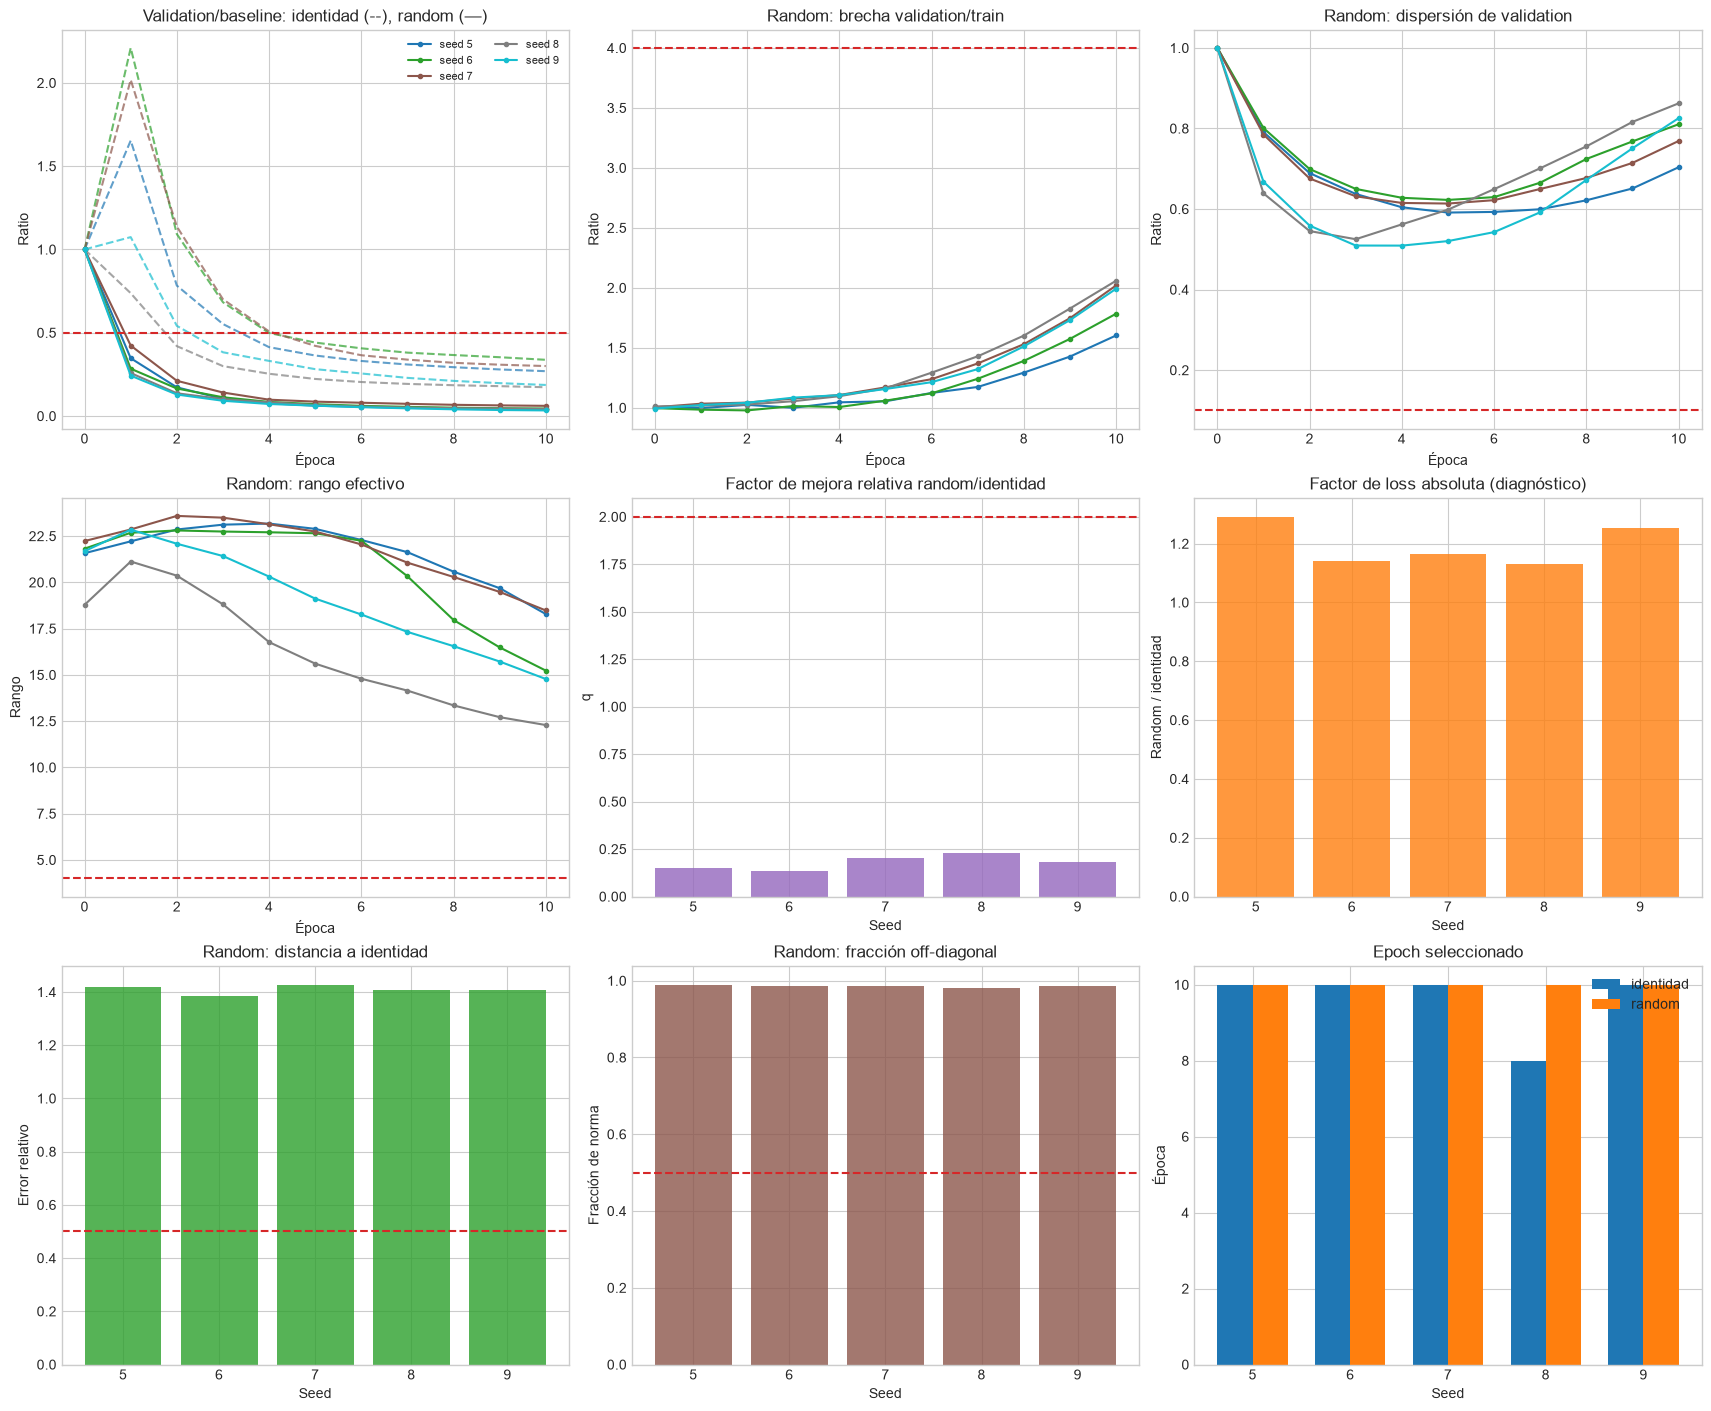

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(17, 14), constrained_layout=True)
colors = plt.cm.tab10(np.linspace(0.0, 1.0, len(config.sweep.seeds)))

for color, seed in zip(colors, config.sweep.seeds, strict=True):
    identity_history = identity_histories[seed]
    random_history = random_histories[seed]
    epochs = np.array([row.epoch for row in random_history])
    identity_val = np.array([row.validation_loss for row in identity_history])
    random_val = np.array([row.validation_loss for row in random_history])
    random_train = np.array([row.train_loss for row in random_history])
    random_std = np.array([row.validation_embedding_std for row in random_history])
    random_rank = np.array([row.validation_effective_rank for row in random_history])
    axes[0, 0].plot(epochs, identity_val / identity_val[0], linestyle="--", color=color, alpha=0.7)
    axes[0, 0].plot(epochs, random_val / random_val[0], marker="o", markersize=3, color=color, label=f"seed {seed}")
    axes[0, 1].plot(epochs, random_val / np.maximum(random_train, 1e-12), marker="o", markersize=3, color=color)
    axes[0, 2].plot(epochs, random_std / random_std[0], marker="o", markersize=3, color=color)
    axes[1, 0].plot(epochs, random_rank, marker="o", markersize=3, color=color)

axes[0, 0].axhline(config.checkpoint_gate.max_validation_loss_ratio, color="tab:red", linestyle="--")
axes[0, 0].set(title="Validation/baseline: identidad (--), random (—)", xlabel="Época", ylabel="Ratio")
axes[0, 0].legend(ncol=2, fontsize=8)
axes[0, 1].axhline(config.checkpoint_gate.max_validation_train_loss_ratio, color="tab:red", linestyle="--")
axes[0, 1].set(title="Random: brecha validation/train", xlabel="Época", ylabel="Ratio")
axes[0, 2].axhline(config.checkpoint_gate.min_validation_embedding_std_ratio, color="tab:red", linestyle="--")
axes[0, 2].set(title="Random: dispersión de validation", xlabel="Época", ylabel="Ratio")
axes[1, 0].axhline(config.checkpoint_gate.min_validation_effective_rank, color="tab:red", linestyle="--")
axes[1, 0].set(title="Random: rango efectivo", xlabel="Época", ylabel="Rango")

comparison_seeds = np.array([row.seed for row in comparison_gate.comparisons])
relative_factors = np.array([row.validation_improvement_ratio for row in comparison_gate.comparisons])
absolute_factors = np.array([row.absolute_validation_loss_ratio for row in comparison_gate.comparisons])
identity_errors = np.array([row.relative_identity_error for row in comparison_gate.comparisons])
off_diagonal = np.array([row.off_diagonal_fraction for row in comparison_gate.comparisons])
random_epochs = np.array([random_summary_by_seed[seed].checkpoint_epoch for seed in comparison_seeds])
identity_epoch_values = np.array([identity_expected_epochs[seed] for seed in comparison_seeds])

axes[1, 1].bar(comparison_seeds, relative_factors, color="tab:purple", alpha=0.8)
axes[1, 1].axhline(config.comparison_gate.max_random_to_identity_validation_improvement_ratio, color="tab:red", linestyle="--")
axes[1, 1].set(title="Factor de mejora relativa random/identidad", xlabel="Seed", ylabel="q")
axes[1, 2].bar(comparison_seeds, absolute_factors, color="tab:orange", alpha=0.8)
axes[1, 2].set(title="Factor de loss absoluta (diagnóstico)", xlabel="Seed", ylabel="Random / identidad")
axes[2, 0].bar(comparison_seeds, identity_errors, color="tab:green", alpha=0.8)
axes[2, 0].axhline(config.comparison_gate.min_random_relative_identity_error, color="tab:red", linestyle="--")
axes[2, 0].set(title="Random: distancia a identidad", xlabel="Seed", ylabel="Error relativo")
axes[2, 1].bar(comparison_seeds, off_diagonal, color="tab:brown", alpha=0.8)
axes[2, 1].axhline(config.comparison_gate.min_random_off_diagonal_fraction, color="tab:red", linestyle="--")
axes[2, 1].set(title="Random: fracción off-diagonal", xlabel="Seed", ylabel="Fracción de norma")
width = 0.36
axes[2, 2].bar(comparison_seeds - width / 2, identity_epoch_values, width=width, label="identidad")
axes[2, 2].bar(comparison_seeds + width / 2, random_epochs, width=width, label="random")
axes[2, 2].set(title="Epoch seleccionado", xlabel="Seed", ylabel="Época")
axes[2, 2].legend()

plt.show()

In [8]:
status = "PASS" if development_passed else "FAIL"
criteria = {
    "replay identidad": identity_replay_passed,
    "encoders pareados": all(paired_encoder_matches.values()),
    "replay random": random_replay_passed,
    "estabilidad random": stability_gate.passed,
    "comparabilidad predictiva": comparison_gate.predictive_comparability_passed,
    "matrices no-identidad": comparison_gate.non_identity_passed,
    "matrices densas": comparison_gate.density_passed,
}
failed_criteria = [name for name, passed in criteria.items() if not passed]
failed_text = ", ".join(failed_criteria) if failed_criteria else "ninguno"
failed_seed_text = ", ".join(str(seed) for seed in comparison_gate.failed_seeds) or "ninguna"
selected_epoch_text = ", ".join(
    f"{summary.seed}:{summary.checkpoint_epoch}" for summary in random_summaries
) or "ninguno"

if comparison_gate.worst_absolute_validation_loss_ratio > comparison_gate.worst_validation_improvement_ratio:
    scale_reading = (
        "La comparación absoluta es más desfavorable que la relativa, compatible con una diferencia de escala latente entre condiciones. "
        "Por eso la loss absoluta permanece diagnóstica."
    )
else:
    scale_reading = (
        "La normalización por baseline no mejora la comparación frente a la loss absoluta; la escala latente no explica por sí sola la diferencia."
    )

decision = (
    "El desarrollo pareado pasa. Los epochs random seleccionados pueden congelarse en un protocolo posterior antes de cualquier evaluación sobre el test ya consumido."
    if development_passed
    else "El desarrollo pareado falla. No corresponde evaluar random en test ni modificar retrospectivamente los umbrales; primero hay que diagnosticar los criterios fallidos con train/validation."
)

display(Markdown(f"""## Resultado e interpretación

- **Gate global de desarrollo: {status}.**
- **Criterios fallidos:** {failed_text}.
- **Seeds comparativas fallidas:** {failed_seed_text}.
- **Epochs random seleccionados:** `{selected_epoch_text}`.
- **Peor factor de mejora relativa random/identidad:** `{comparison_gate.worst_validation_improvement_ratio:.3f}` frente al máximo `{config.comparison_gate.max_random_to_identity_validation_improvement_ratio:.1f}`.
- **Peor factor de loss absoluta:** `{comparison_gate.worst_absolute_validation_loss_ratio:.3f}`; diagnóstico no vinculante.
- **Mínima distancia a identidad:** `{comparison_gate.minimum_relative_identity_error:.1%}` frente al mínimo `{config.comparison_gate.min_random_relative_identity_error:.0%}`.
- **Mínima fracción off-diagonal:** `{comparison_gate.minimum_off_diagonal_fraction:.1%}` frente al mínimo `{config.comparison_gate.min_random_off_diagonal_fraction:.0%}`.
- **CV de mejoras random:** `{stability_gate.validation_loss_ratio_coefficient_of_variation:.3f}` frente al máximo `{config.stability_gate.max_validation_loss_ratio_coefficient_of_variation:.2f}`.

### Lectura de los gráficos

Las curvas punteadas y sólidas del primer panel comparan condiciones con el mismo color por seed. Los tres paneles siguientes controlan que el resultado random no se obtenga mediante overfitting o colapso. Los paneles inferiores separan desempeño relativo, escala absoluta y estructura de `M`. {scale_reading}

Una matriz puede ser predictivamente útil sin acercarse a identidad: ésa es justamente la hipótesis de cambio de base que prueba este control. Distancia a identidad y densidad no son métricas de calidad predictiva; sólo verifican que el tratamiento realmente produjo la estructura alternativa esperada.

### Decisión

{decision} Este notebook no construyó ni consultó test. Incluso un PASS sólo valida el control en desarrollo; todavía no demuestra comparabilidad fuera de muestra ni reproduce el paper a escala completa.
"""))

## Resultado e interpretación

- **Gate global de desarrollo: PASS.**
- **Criterios fallidos:** ninguno.
- **Seeds comparativas fallidas:** ninguna.
- **Epochs random seleccionados:** `5:10, 6:10, 7:10, 8:10, 9:10`.
- **Peor factor de mejora relativa random/identidad:** `0.229` frente al máximo `2.0`.
- **Peor factor de loss absoluta:** `1.291`; diagnóstico no vinculante.
- **Mínima distancia a identidad:** `138.4%` frente al mínimo `50%`.
- **Mínima fracción off-diagonal:** `98.2%` frente al mínimo `50%`.
- **CV de mejoras random:** `0.204` frente al máximo `0.25`.

### Lectura de los gráficos

Las curvas punteadas y sólidas del primer panel comparan condiciones con el mismo color por seed. Los tres paneles siguientes controlan que el resultado random no se obtenga mediante overfitting o colapso. Los paneles inferiores separan desempeño relativo, escala absoluta y estructura de `M`. La comparación absoluta es más desfavorable que la relativa, compatible con una diferencia de escala latente entre condiciones. Por eso la loss absoluta permanece diagnóstica.

Una matriz puede ser predictivamente útil sin acercarse a identidad: ésa es justamente la hipótesis de cambio de base que prueba este control. Distancia a identidad y densidad no son métricas de calidad predictiva; sólo verifican que el tratamiento realmente produjo la estructura alternativa esperada.

### Decisión

El desarrollo pareado pasa. Los epochs random seleccionados pueden congelarse en un protocolo posterior antes de cualquier evaluación sobre el test ya consumido. Este notebook no construyó ni consultó test. Incluso un PASS sólo valida el control en desarrollo; todavía no demuestra comparabilidad fuera de muestra ni reproduce el paper a escala completa.


## Auditoría posterior a la ejecución

La ejecución confirma el **PASS de desarrollo** sin abrir test. Los cinco checkpoints identidad se reprodujeron exactamente; los cinco modelos Xavier comenzaron con encoders online y target idénticos a sus pares y también reprodujeron exactamente el checkpoint seleccionado. Todas las corridas random eligieron epoch 10.

El panel superior izquierdo muestra una diferencia sistemática: identidad tiene un aumento transitorio de loss relativa en epoch 1, mientras Xavier desciende desde el inicio. Al final, random alcanza `validation/baseline` entre `0.034` y `0.061`; el CV entre seeds es `0.204`. La brecha validation/train crece durante el entrenamiento, pero su peor valor es `2.059`, lejos del límite `4.0`. La dispersión conserva al menos `70.4%` del baseline y el rango efectivo final nunca baja de `12.29`, por lo que esta mejora no se explica por colapso según los criterios congelados.

La comparación pareada requiere distinguir dos afirmaciones. El factor relativo `q` está entre `0.133` y `0.229`: Xavier reduce su loss respecto de su propio baseline más que identidad. Sin embargo, su loss absoluta final es `1.129–1.291x` la de identidad. No hay contradicción: cada condición aprende un sistema de coordenadas latentes cuya escala puede ser diferente, y por eso la métrica absoluta quedó como diagnóstico no vinculante antes de ejecutar.

El tratamiento estructural funcionó con margen amplio. La menor distancia relativa a identidad es `138.4%` y la menor fracción off-diagonal es `98.2%`, frente a mínimos predefinidos de `50%`. En otras palabras, el buen error predictivo relativo no obliga a que `M` sea casi identidad: una matriz densa y lejana de `I` también puede predecir bien en otra base latente.

Ésta sigue siendo evidencia de **train/validation**. No sabemos todavía si los embeddings random conservan separación de regímenes en held-out ni cómo se comparan allí con identidad. El próximo paso permitido es congelar estos epochs en un protocolo separado y recién entonces evaluar ambas condiciones sobre el test smoke ya consumido, dejando explícito que esa comparación no será una segunda evaluación ciega.
